#Pipleline

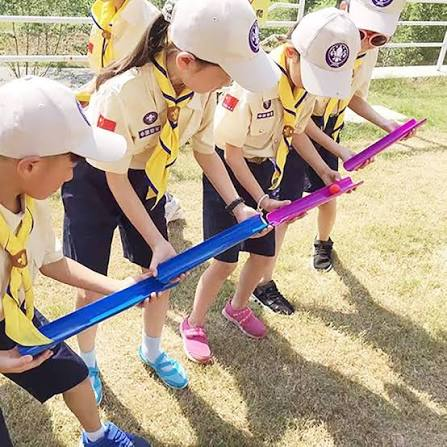

Transformer -- Filter or Modifying the Data
      
	  Classes - Fit() , Transform()

Estimator -- Learn From the data
      
	  Classes - Fit() , Predict()




Transformer :

learn from data , apply , edit in data


StandardScaler → Scaling

MinMaxScaler → Scaling

OneHotEncoder → Encoding

OrdinalEncoder → Encoding

PCA → Dimensionality Reduction

--------------

Estimator

learn from data / prediction / ML task

LogisticRegression

LinearRegression

SVC

KNeighborsClassifier

DecisionTreeClassifier

GaussianNB

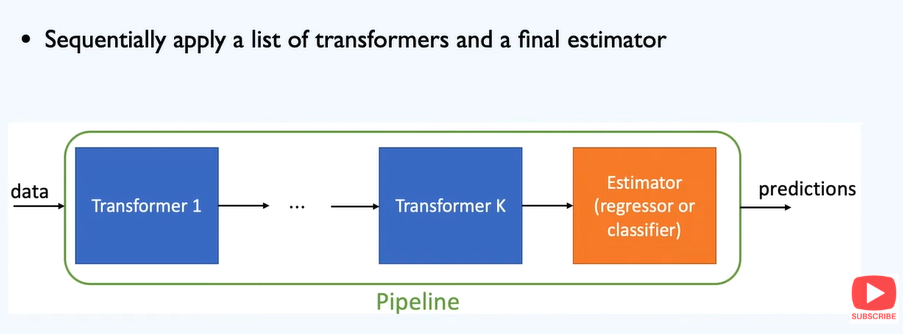

Examples Transfomer :

1- SimpleImputer()

2- Scaler()

3- Encoder()

-----------------------------

Example For Pipleine :

pipleine 1
   
   simpleImputer() + Scaler()

pipeline 2
   
   simpleimputer() + Encoder()


-----------------------------

Transformer is the smallest part

pipleline is many transformers

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
import numpy as np



from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression


from sklearn.pipeline import Pipeline

In [ ]:
df=pd.read_excel("/content/pipleline.xlsx")

In [ ]:
df

,age,gender,height,weight,gluc,smoke,active
0,20.0,0.0,168.0,62,1,1,1
1,21.0,1.0,156.0,85,0,1,1
2,NaN,1.0,165.0,64,1,1,0
3,25.0,0.0,169.0,82,0,0,1
4,24.0,1.0,156.0,56,1,0,0
5,NaN,NaN,172.0,75,0,1,1
6,35.0,1.0,160.0,70,1,1,1
7,33.0,0.0,175.0,85,0,0,0
8,36.0,1.0,NaN,67,1,0,1
9,26.0,0.0,168.0,77,0,0,1


In [ ]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'gluc', 'smoke', 'active'], dtype='object')

##I will put all the categories Column in one list

In [ ]:
# X = Features
X = df.drop('active', axis=1)

# y = Target
y = df['active']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:")
display(X_train)

print("X_test:")
display(X_test)

print("y_train:")
display(y_train)

print("y_test:")
display(y_test)

X_train:


,age,gender,height,weight,gluc,smoke
13,55.0,0.0,172.0,76,0,0
11,31.0,0.0,170.0,80,0,0
8,36.0,1.0,NaN,67,1,0
9,26.0,0.0,168.0,77,0,0
2,NaN,1.0,165.0,64,1,1
15,62.0,0.0,169.0,74,0,0
4,24.0,1.0,156.0,56,1,0
7,33.0,0.0,175.0,85,0,0
10,27.0,1.0,162.0,65,1,1
12,45.0,1.0,164.0,69,1,1


X_test:


,age,gender,height,weight,gluc,smoke
0,20.0,0.0,168.0,62,1,1
1,21.0,1.0,156.0,85,0,1
5,NaN,NaN,172.0,75,0,1
14,57.0,1.0,158.0,62,1,1


y_train:


,active
13,1
11,1
8,1
9,1
2,0
15,1
4,0
7,0
10,0
12,1


y_test:


,active
0,1
1,1
5,1
14,0


In [ ]:
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_cols = ['gender', 'cholesterol', 'gluc']

---------------------------

انا عندي في الداتا انواع كتير من الداتا

داتا text

داتا numeric

و كل نوع انا بتعامل معاه بطريقة مختلفة عن التاني


مثلا الداتا الtext
بحتاج اني احولها لارقام

و الداتا الارقام بحتاج اعملها سكالنج

-------------------------

Craete the pipleline :

pipeline text data , pipleline Numeric Data


b3d kada agm3hom m3 b3d

-------------------------------

1. Numerical Pipeline

1. from sklearn.pipeline import Pipeline

2. Pipeline(steps=[])

3. Pipeline(steps=

    [
  
    (الخطوة الاولي),

   
    (الخطوة التانية)

    ])

In [ ]:
numerical_Pipeline = Pipeline(steps=
 [
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
 ])

In [ ]:
numerical_Pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

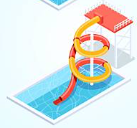

--------------

2.  Categorical Pipeline

In [ ]:
categorical_Pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
categorical_Pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

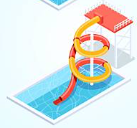

----------------------------------------

3. ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_Pipeline, numerical_cols),
        ('cat', categorical_Pipeline, categorical_cols)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'height', 'weight', 'ap_hi', 'ap_lo']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'cholesterol', 'gluc'])])

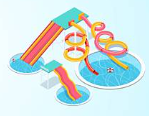

Transformer is the smallest part

pipleline is many transformers in sequence

ColumnTransformer apply different pipelines to different Data/columns

In [ ]:
# Define the model pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [ ]:
model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'height', 'weight',
                                                   'ap_hi', 'ap_lo']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'cholesterol',
                                                   'gluc'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

#Project

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns




df = pd.read_excel("/content/pipleline.xlsx")




print("Shape:", df.shape)

display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())



X = df.drop('active', axis=1)

y = df['active']


y=y.replace({
    'yes':1,
    'No':0
})

numerical_cols = [
    'age',
    'height',
    'weight',
    'gluc'
]

categorical_cols = [
    'gender',
    'smoke'
]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)


model = LogisticRegression(
    max_iter=1000
)

final_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)




final_pipeline.fit(
    X_train,
    y_train
)



y_pred = final_pipeline.predict(X_test)




accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)




#-------------------------------------------------------------------




new_person = pd.DataFrame({
    'age': [30],
    'gender': ['No'],
    'height': [170],
    'weight': [75],
    'gluc': [150],
    'smoke': ['yes']
})


prediction = final_pipeline.predict(
    new_person
)

print("Prediction:", prediction)


probability = final_pipeline.predict_proba(
    new_person
)

print("Probability:", probability)

Shape: (16, 7)


,age,gender,height,weight,gluc,smoke,active
0,20.0,No,168.0,62,180,yes,yes
1,21.0,yes,156.0,85,150,yes,yes
2,NaN,yes,165.0,64,120,yes,No
3,25.0,No,169.0,82,130,No,yes
4,24.0,yes,156.0,56,140,No,No



Missing Values:
age       2
gender    1
height    1
weight    0
gluc      0
smoke     0
active    0
dtype: int64
Accuracy: 0.75
Prediction: [1]
Probability: [[0.17529883 0.82470117]]


/tmp/ipykernel_3020/1366244900.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y=y.replace({
